### Project Title:  House Price Prediction

#### Prepared By:
- Name: Abhishek Sahu
- Domain: Data Science
- ID : CT_CSI_DS_5981

- Dataset Link: https://view.officeapps.live.com/op/view.aspx?src=https%3A%2F%2Fmedia.geeksforgeeks.org%2Fwp-content%2Fuploads%2F20240905183434%2FHousePricePrediction.xlsx&wdOrigin=BROWSELINK

#### Project Overview:
This project aims to build a predictive regression model to estimate house sale prices using property features from the HousePriceMerged dataset. The dataset contains 13 features describing structural, zoning, and lot characteristics of residential properties.

Through exploratory data analysis (EDA), data cleaning, feature engineering, and model building, the project will uncover key drivers of house prices and produce an accurate, interpretable prediction tool for real-estate valuation.

#### Feature Overview:

| **Column Name** | **Description / Type**                             |
| --------------- | -------------------------------------------------- |
| Id              | Unique identifier (Numeric)                        |
| MSSubClass      | Building class category (Numeric / Categorical)    |
| MSZoning        | Zoning classification (Categorical)                |
| LotArea         | Lot size in square feet (Numeric)                  |
| LotConfig       | Lot configuration (Categorical)                    |
| BldgType        | Type of dwelling (Categorical)                     |
| OverallCond     | Overall condition (Numeric ordinal 1–10)           |
| YearBuilt       | Original construction year (Numeric)               |
| YearRemodAdd    | Remodel year (Numeric)                             |
| Exterior1st     | Exterior covering type (Categorical)               |
| BsmtFinSF2      | Finished basement area (Numeric)                   |
| TotalBsmtSF     | Total basement area (Numeric)                      |
| SalePrice       | Target variable: Sale price of the house (Numeric) |

#### Key Objectives:
Perform EDA to understand distributions, relationships, and trends.

Handle missing values and prepare data with encoding/scaling.

Identify important features impacting sale price.

Train and evaluate regression models (e.g., Linear Regression, Random Forest).

Interpret model results to provide actionable insights.

#### Outcome:
A well-validated machine learning model capable of estimating house prices based on input features, supporting data-driven decision-making in real estate pricing and investment.

### Dataset Metadata

| **Property**            | **Value**                                     |
| ----------------------- | --------------------------------------------- |
| **File Name**           | HousePriceMerged.csv                          |
| **Number of Instances** | (depends on your rows, typically \~1000–1500) |
| **Number of Features**  | 13                                            |
| **Target Variable**     | SalePrice                                     |
| **Missing Values**      | To be checked (some fields may have NaNs)     |
| **Feature Types**       | Mixed (Numeric & Categorical)                 |


### Importing necessary libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\sahua\OneDrive\Desktop\Data_science\Celebal Technology\Week5_Task\HousePriceMerged.csv")

### Data Profiling

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [4]:
df.tail()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN
2918,2918,60,RL,9627,Inside,1Fam,5,1993,1994,HdBoard,0.0,996.0,NaN


In [4]:
df.shape

(2919, 13)

In [5]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='object')

In [5]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [7]:
s = (df.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)

s = (df.dtypes == 'int64')
num_cols = list(s[s].index)
print("Integer variables:")
print(num_cols)

s = (df.dtypes == 'float64')
num_cols = list(s[s].index)
print("Real variables:")
print(num_cols)

Categorical variables:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
Integer variables:
['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd']
Real variables:
['BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']


In [6]:
df.nunique()

Id              2919
MSSubClass        16
MSZoning           5
LotArea         1951
LotConfig          5
BldgType           5
OverallCond        9
YearBuilt        118
YearRemodAdd      61
Exterior1st       15
BsmtFinSF2       272
TotalBsmtSF     1058
SalePrice        663
dtype: int64

In [9]:
print(df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64


<Axes: title={'center': 'Heatmap of missing values'}>

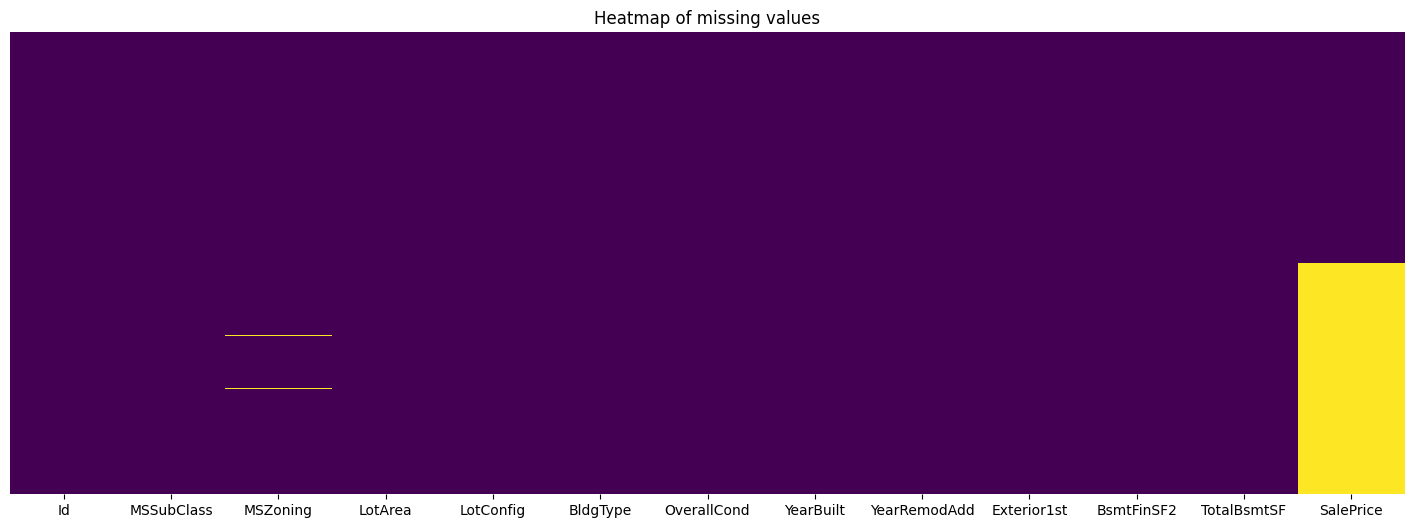

In [10]:
plt.figure(figsize=(18,6))
plt.title('Heatmap of missing values')
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [8]:
# List of categorical variables
categorical_cols = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']

# Analyzing categorical variables
for col in categorical_cols:
    print(df[col].value_counts())


MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64
LotConfig
Inside     2133
Corner      511
CulDSac     176
FR2          85
FR3          14
Name: count, dtype: int64
BldgType
1Fam      2425
TwnhsE     227
Duplex     109
Twnhs       96
2fmCon      62
Name: count, dtype: int64
Exterior1st
VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
Name: count, dtype: int64


In [9]:
# List of numerical variables
numerical_cols = ['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd']

# Summary statistics of numerical variables
print(df[numerical_cols].describe())

                Id   MSSubClass        LotArea  OverallCond    YearBuilt  \
count  2919.000000  2919.000000    2919.000000  2919.000000  2919.000000   
mean   1459.000000    57.137718   10168.114080     5.564577  1971.312778   
std     842.787043    42.517628    7886.996359     1.113131    30.291442   
min       0.000000    20.000000    1300.000000     1.000000  1872.000000   
25%     729.500000    20.000000    7478.000000     5.000000  1953.500000   
50%    1459.000000    50.000000    9453.000000     5.000000  1973.000000   
75%    2188.500000    70.000000   11570.000000     6.000000  2001.000000   
max    2918.000000   190.000000  215245.000000     9.000000  2010.000000   

       YearRemodAdd  
count   2919.000000  
mean    1984.264474  
std       20.894344  
min     1950.000000  
25%     1965.000000  
50%     1993.000000  
75%     2004.000000  
max     2010.000000  


### Data Visualization

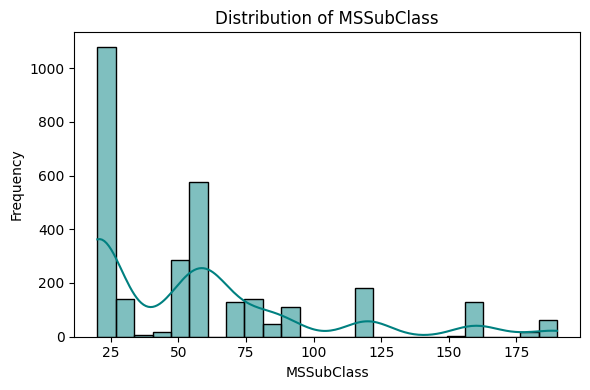

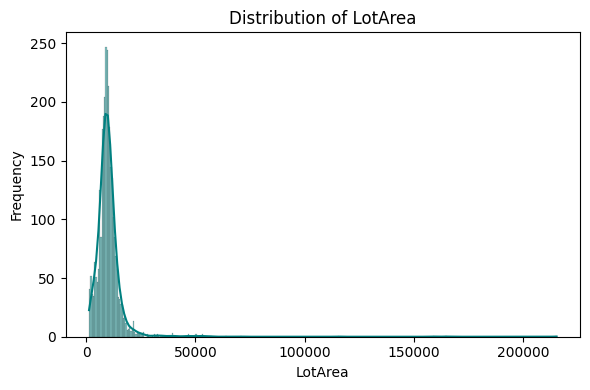

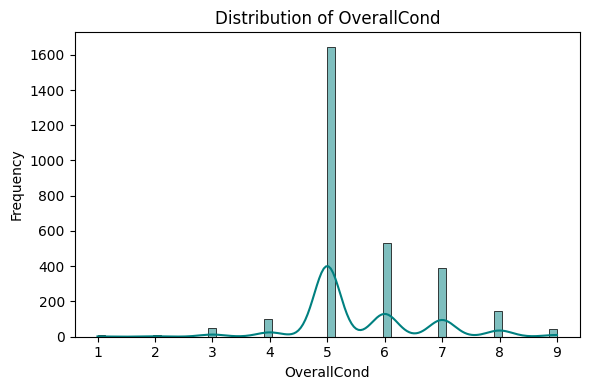

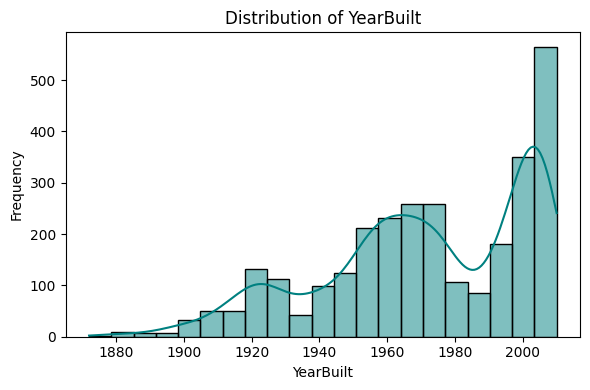

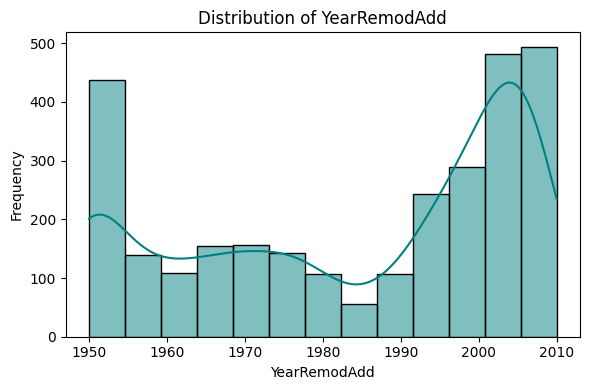

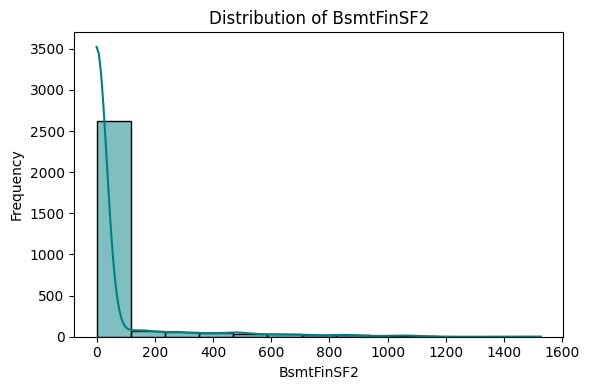

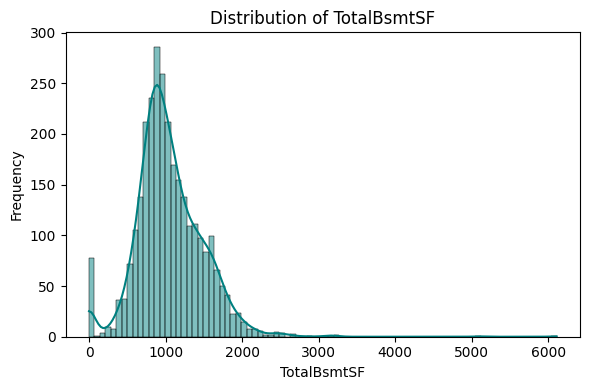

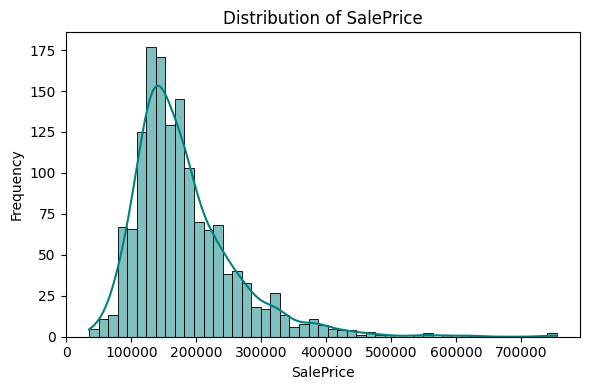

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

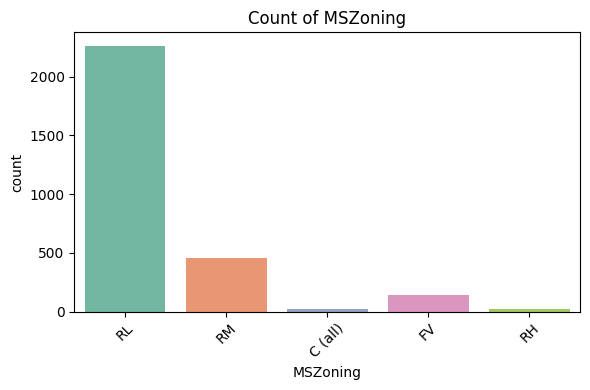

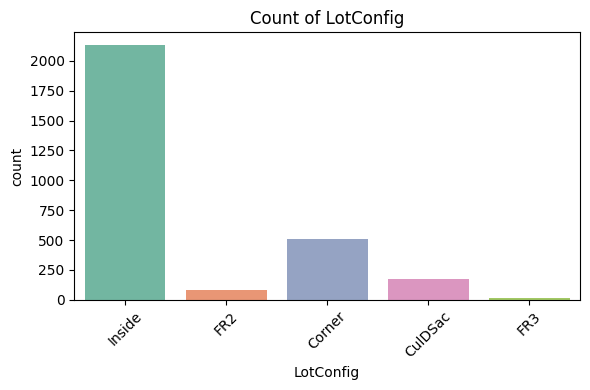

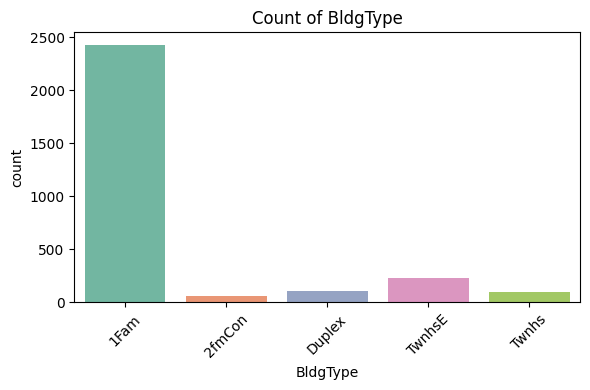

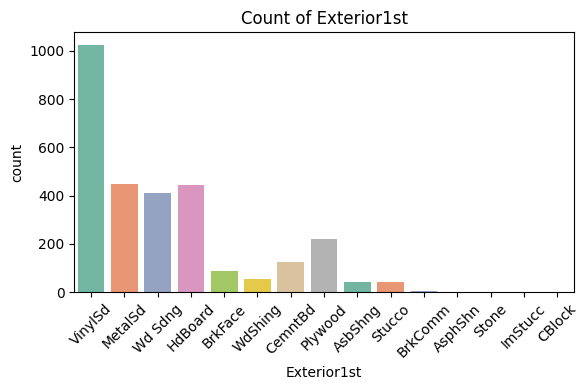

In [14]:
categorical_cols = ['MSZoning','LotConfig', 'BldgType', 'Exterior1st']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, palette='Set2')
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

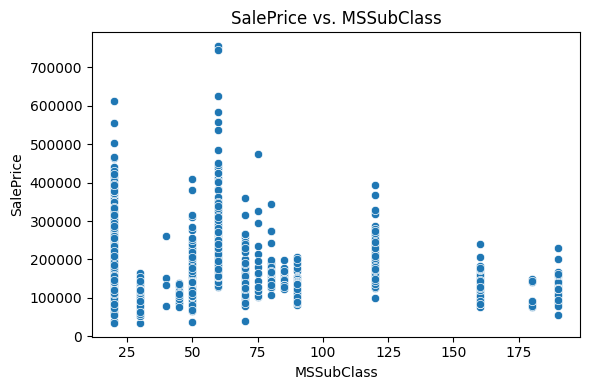

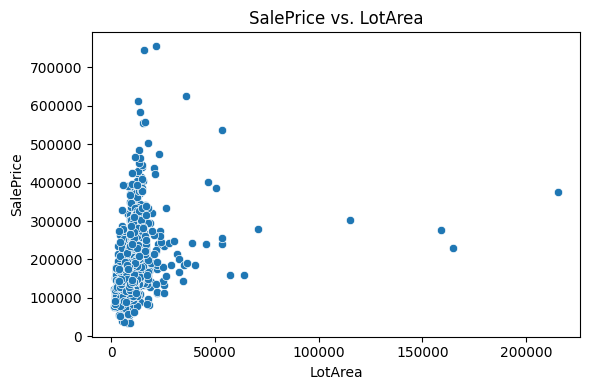

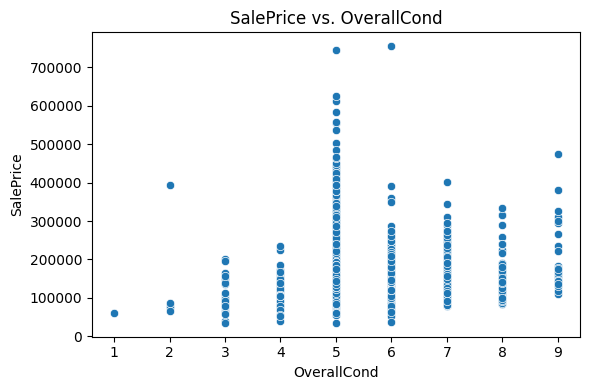

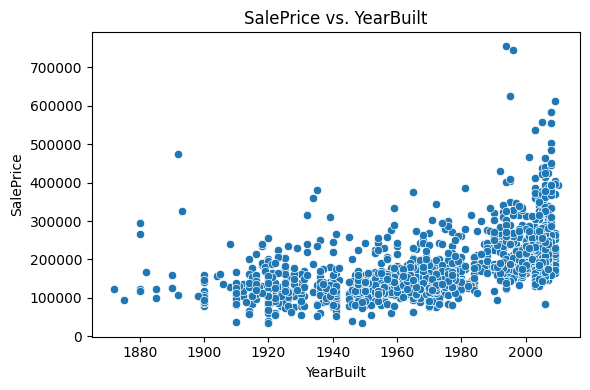

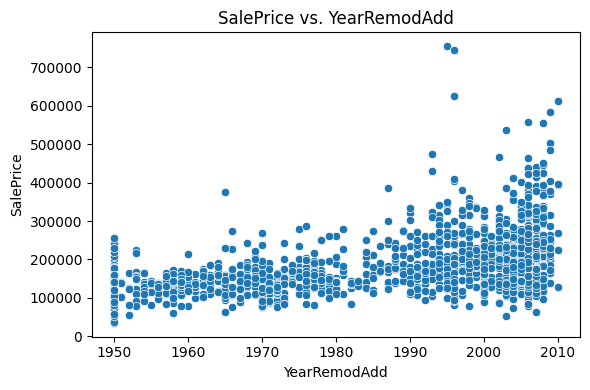

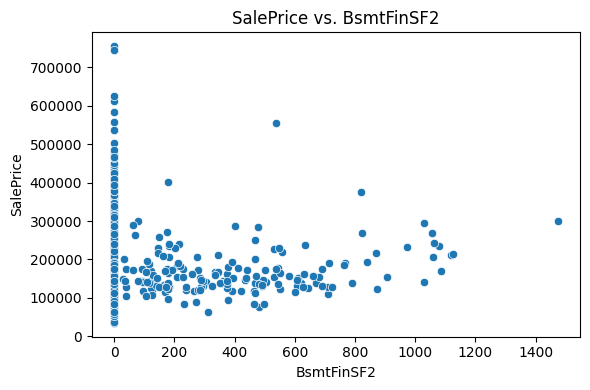

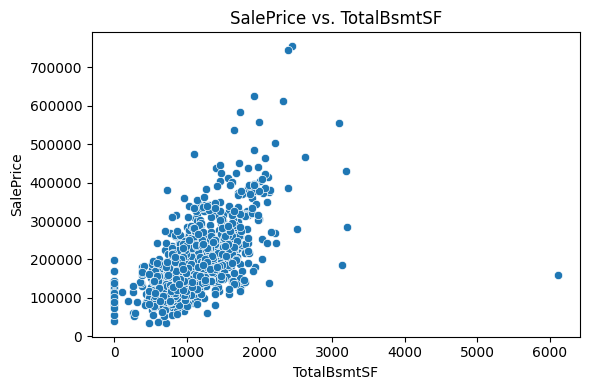

In [15]:
for col in numeric_cols:
    if col != 'SalePrice':
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=col, y='SalePrice', data=df)
        plt.title(f'SalePrice vs. {col}')
        plt.tight_layout()
        plt.show()


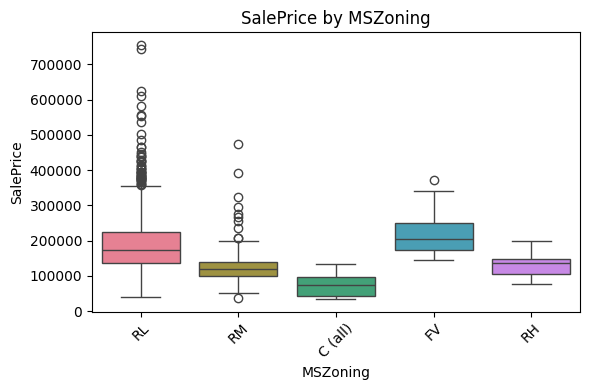

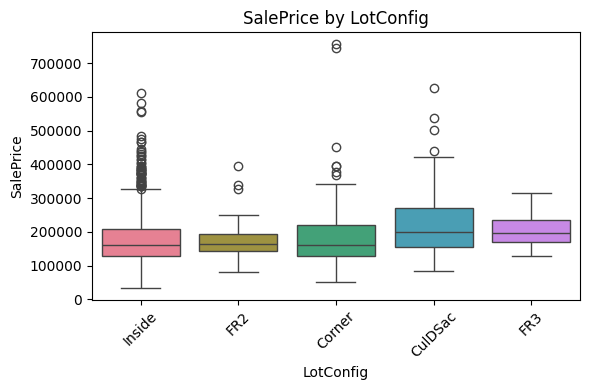

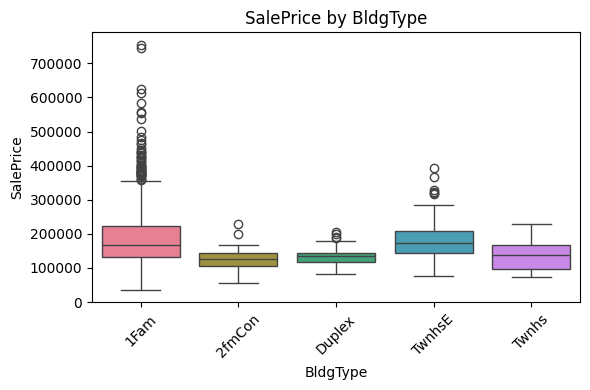

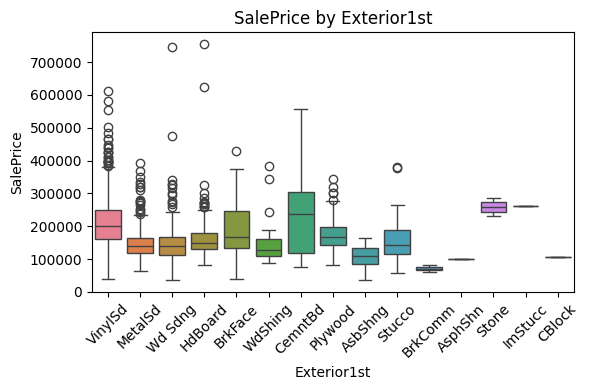

In [16]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=col, y='SalePrice', data=df, palette='husl')
    plt.title(f'SalePrice by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


<Axes: title={'center': 'No. Unique values of Categorical Features'}>

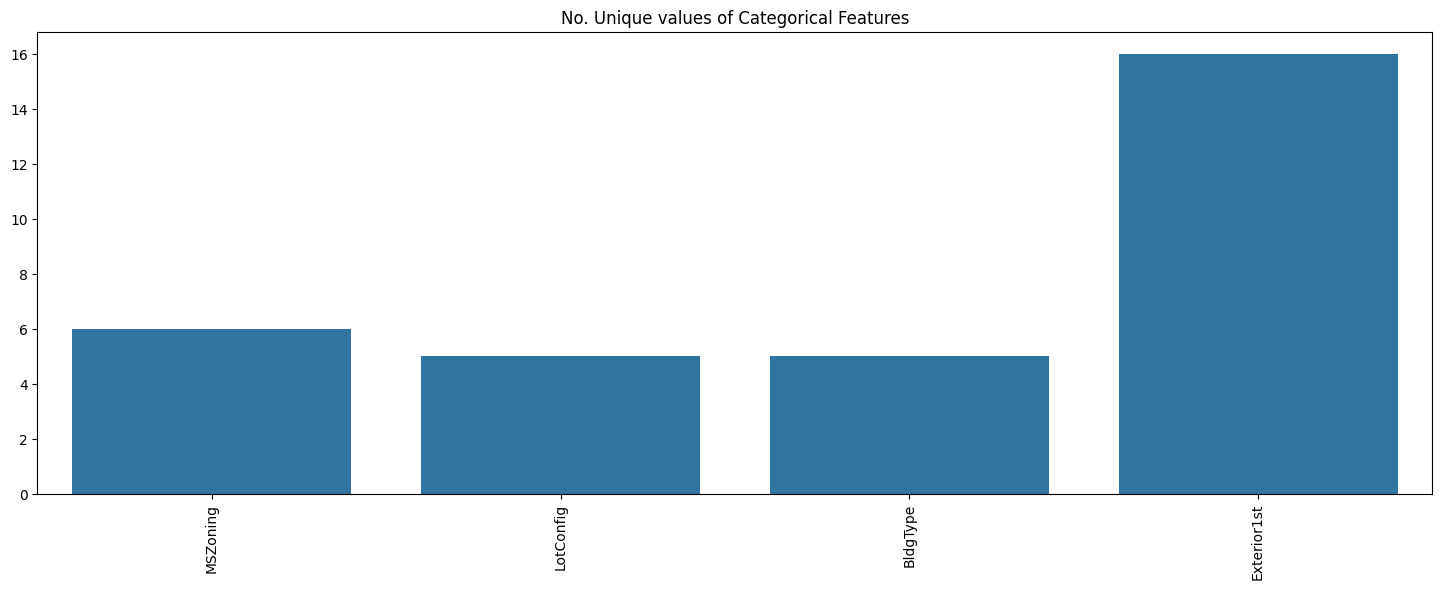

In [11]:
unique_values = []
for col in object_cols:
  unique_values.append(df[col].unique().size)
plt.figure(figsize=(18,6))
plt.title('No. Unique values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=object_cols,y=unique_values)

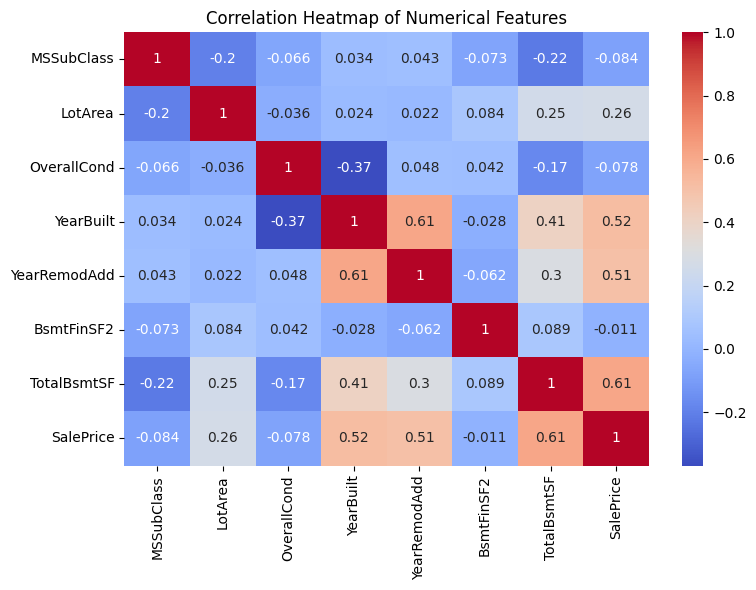

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


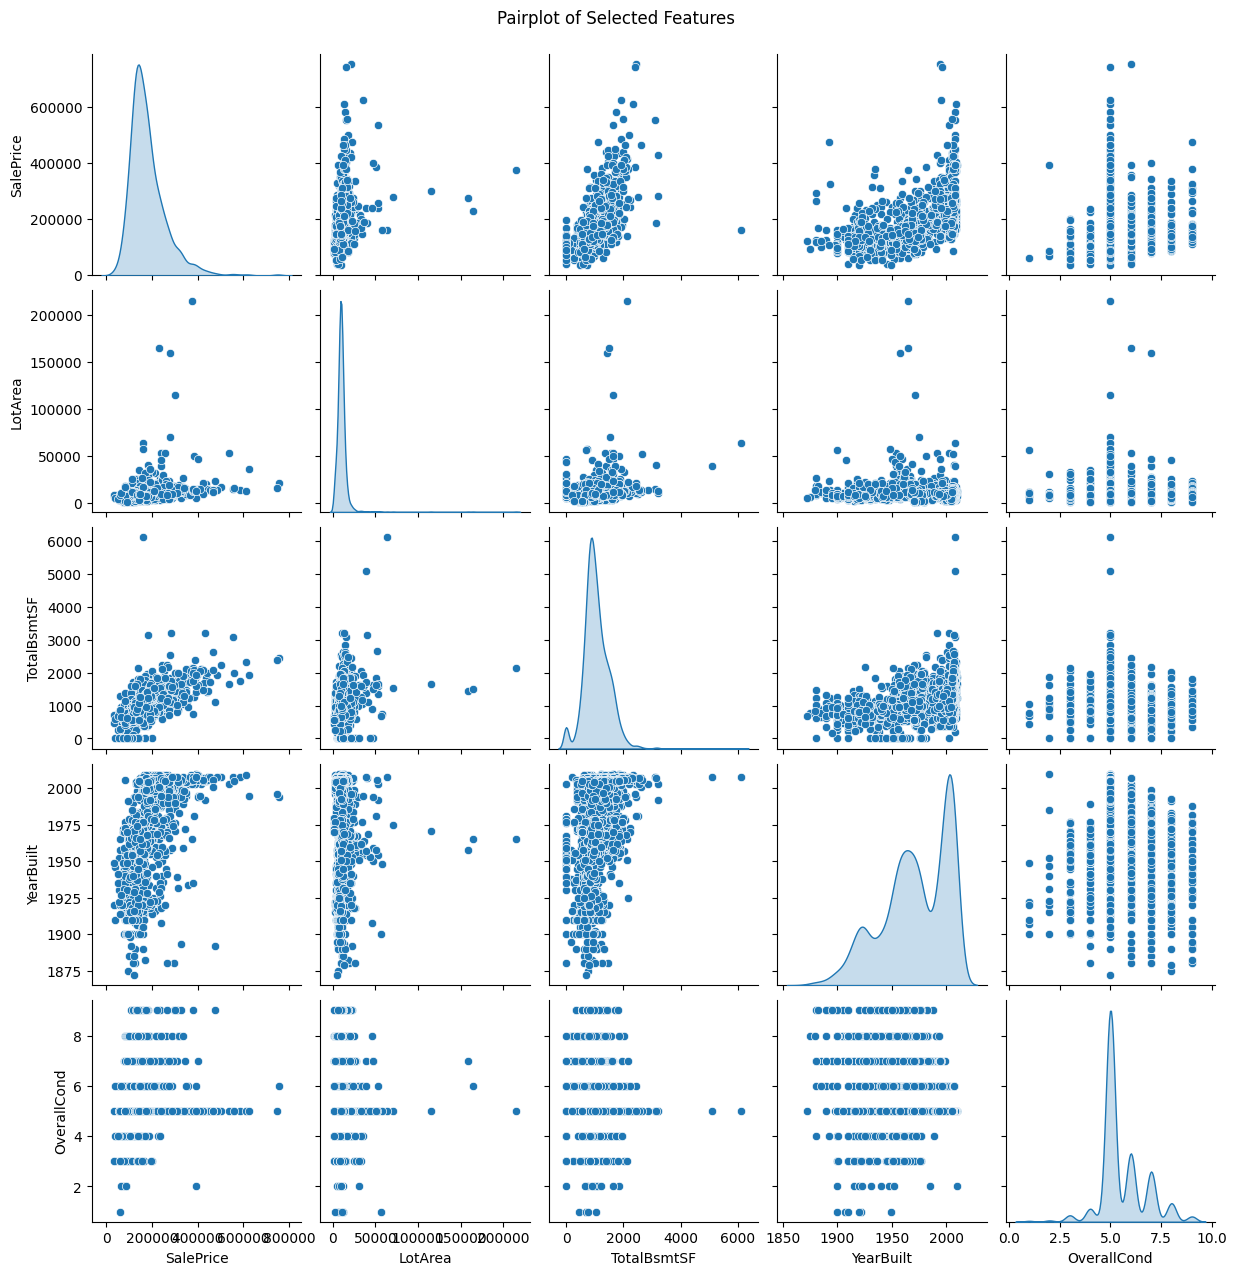

In [18]:
selected_cols = ['SalePrice', 'LotArea', 'TotalBsmtSF', 'YearBuilt', 'OverallCond']
sns.pairplot(df[selected_cols], diag_kind='kde')
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()


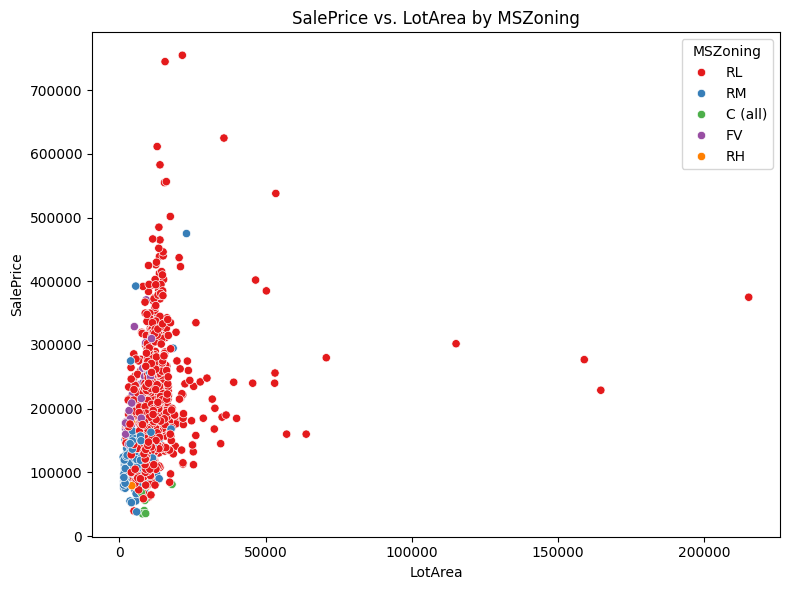

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='LotArea', y='SalePrice', hue='MSZoning', data=df, palette='Set1')
plt.title('SalePrice vs. LotArea by MSZoning')
plt.tight_layout()
plt.show()


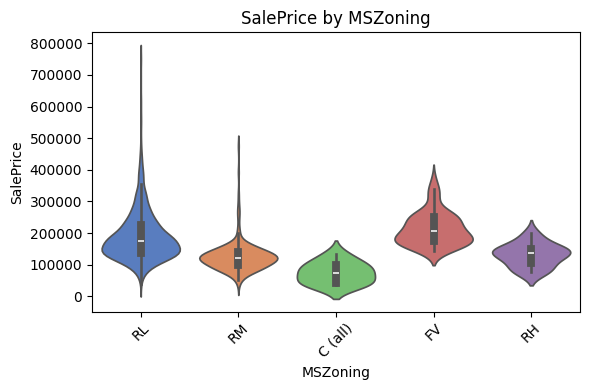

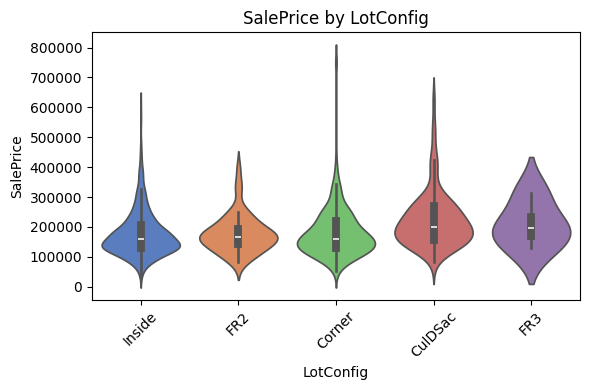

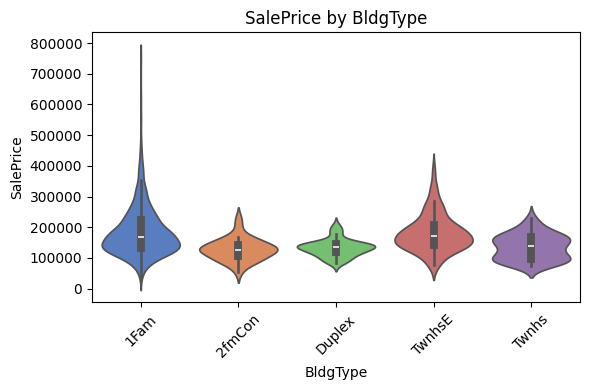

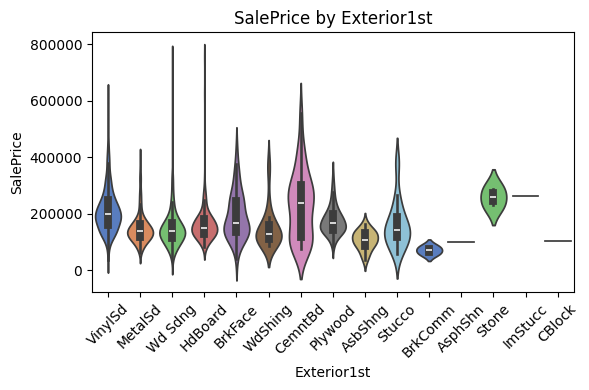

In [20]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(x=col, y='SalePrice', data=df, palette='muted')
    plt.title(f'SalePrice by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


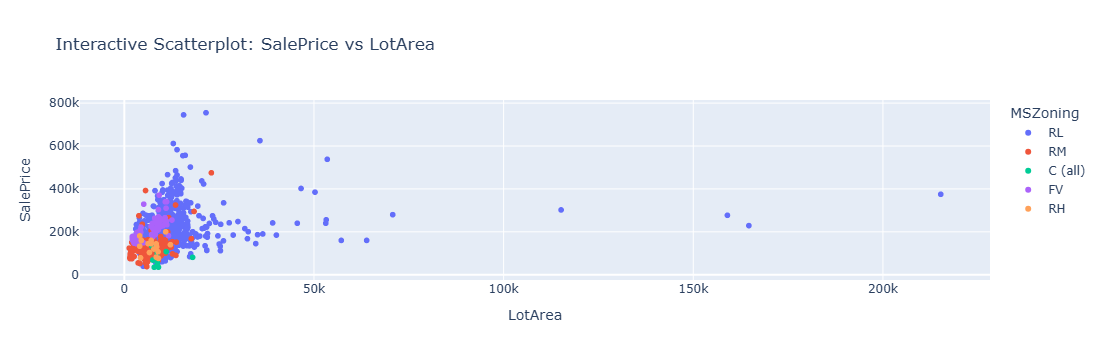

In [21]:
import plotly.express as px

fig = px.scatter(df, x='LotArea', y='SalePrice', color='MSZoning', title='Interactive Scatterplot: SalePrice vs LotArea')
fig.show()

### Data PreProcessing

In [22]:
df['MSZoning'] = df['MSZoning'].fillna(df['MSZoning'].mode()[0])

df['Exterior1st'] = df['Exterior1st'].fillna(df['Exterior1st'].mode()[0])

df['BsmtFinSF2'] = df['BsmtFinSF2'].fillna(int(0))

df['TotalBsmtSF'] = df['TotalBsmtSF'].fillna(int(0))

In [23]:
print(df.isnull().sum().sum())

1459


In [24]:
df.drop(['Id'],axis=1,inplace=True)

df['SalePrice'] = df['SalePrice'].fillna(df['SalePrice'].mean())

In [25]:
print(df.isnull().sum())

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64


In [26]:
from sklearn.preprocessing import OneHotEncoder

s = (df.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)
print('No. of. categorical features: ',len(object_cols))

Categorical variables:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No. of. categorical features:  4


In [27]:
OH_encoder = OneHotEncoder(sparse_output=False)
OH_cols = pd.DataFrame(OH_encoder.fit_transform(df[object_cols]))
OH_cols.index = df.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = df.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)

In [28]:
df_final.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_C (all),MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,60,8450,5,2003,2003,0.0,856.0,208500.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,20,9600,8,1976,1976,0.0,1262.0,181500.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,60,11250,5,2001,2002,0.0,920.0,223500.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,70,9550,5,1915,1970,0.0,756.0,140000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,60,14260,5,2000,2000,0.0,1145.0,250000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [34]:
df_final.describe()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_C (all),MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,...,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.565262,1051.417266,180921.195890,0.008565,0.047619,...,0.043165,0.151422,0.000343,0.154162,0.075711,0.000685,0.014731,0.351490,0.140802,0.019185
std,42.517628,7886.996359,1.113131,30.291442,20.894344,169.179104,441.120498,56174.332503,0.092164,0.212995,...,0.203264,0.358521,0.018509,0.361166,0.264580,0.026171,0.120495,0.477518,0.347876,0.137197
min,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,163000.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.000000,180921.195890,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,180921.195890,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [29]:
df_final.dtypes

MSSubClass               int64
LotArea                  int64
OverallCond              int64
YearBuilt                int64
YearRemodAdd             int64
BsmtFinSF2             float64
TotalBsmtSF            float64
SalePrice              float64
MSZoning_C (all)       float64
MSZoning_FV            float64
MSZoning_RH            float64
MSZoning_RL            float64
MSZoning_RM            float64
LotConfig_Corner       float64
LotConfig_CulDSac      float64
LotConfig_FR2          float64
LotConfig_FR3          float64
LotConfig_Inside       float64
BldgType_1Fam          float64
BldgType_2fmCon        float64
BldgType_Duplex        float64
BldgType_Twnhs         float64
BldgType_TwnhsE        float64
Exterior1st_AsbShng    float64
Exterior1st_AsphShn    float64
Exterior1st_BrkComm    float64
Exterior1st_BrkFace    float64
Exterior1st_CBlock     float64
Exterior1st_CemntBd    float64
Exterior1st_HdBoard    float64
Exterior1st_ImStucc    float64
Exterior1st_MetalSd    float64
Exterior

### Comparision of diff. Modeling

In [30]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

X = df_final.drop(['SalePrice'], axis=1)
Y = df_final['SalePrice']

x_train, x_valid, y_train, y_valid = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=7)

#### Linear regression

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

model_LR = LinearRegression()
model_LR.fit(x_train, y_train)
Y_pred = model_LR.predict(x_valid)

print(mean_absolute_percentage_error(y_valid, Y_pred))

0.1851945728981843


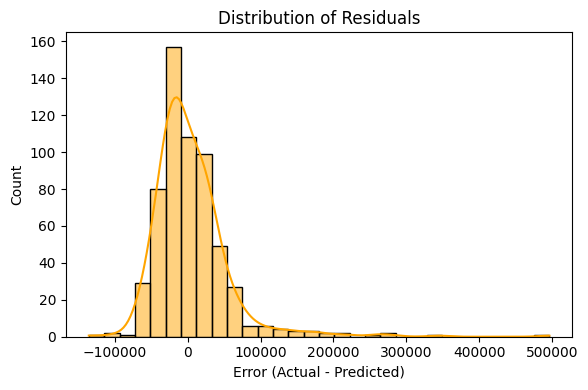

In [33]:
residuals = y_valid - Y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True, color='orange')
plt.title('Distribution of Residuals')
plt.xlabel('Error (Actual - Predicted)')
plt.tight_layout()
plt.show()


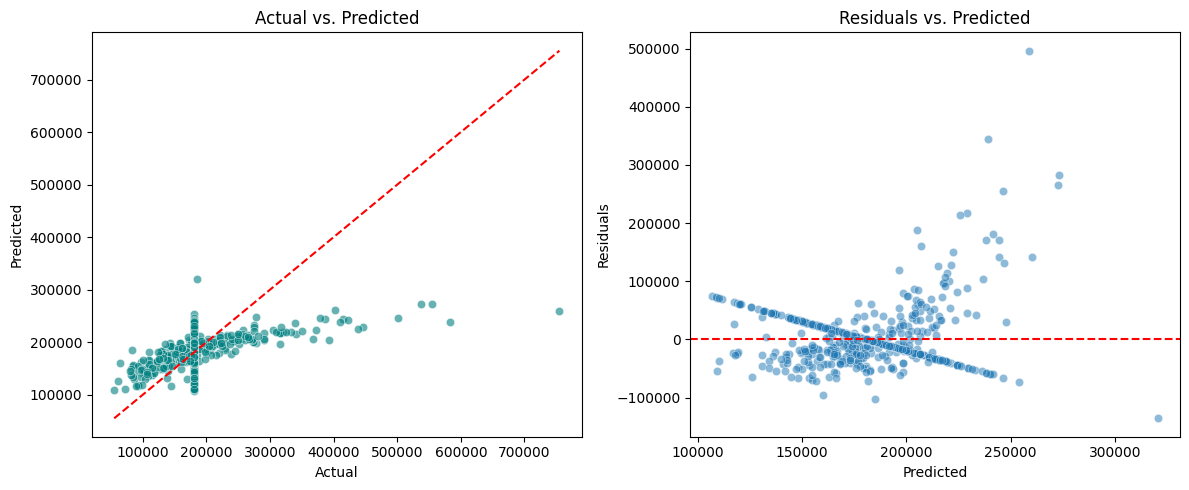

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted
sns.scatterplot(x=y_valid, y=Y_pred, ax=axes[0], color='teal', alpha=0.6)
axes[0].plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], color='red', linestyle='--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs. Predicted')

# Residuals
sns.scatterplot(x=Y_pred, y=residuals, ax=axes[1], alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs. Predicted')

plt.tight_layout()
plt.show()


In [35]:
from sklearn import svm
from sklearn.svm import SVC

model_SVR = svm.SVR()
model_SVR.fit(x_train,y_train)
Y_pred = model_SVR.predict(x_valid)

print(mean_absolute_percentage_error(y_valid, Y_pred))

0.17597400588141962


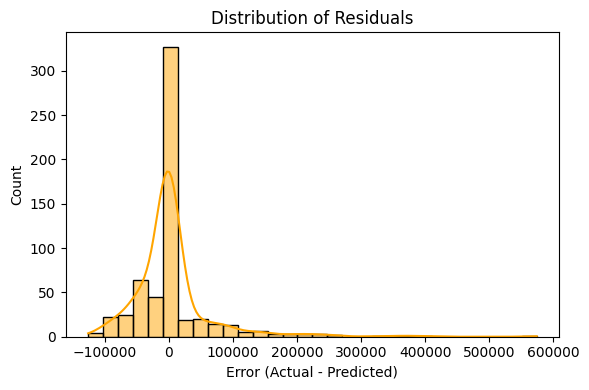

In [36]:
residuals = y_valid - Y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True, color='orange')
plt.title('Distribution of Residuals')
plt.xlabel('Error (Actual - Predicted)')
plt.tight_layout()
plt.show()


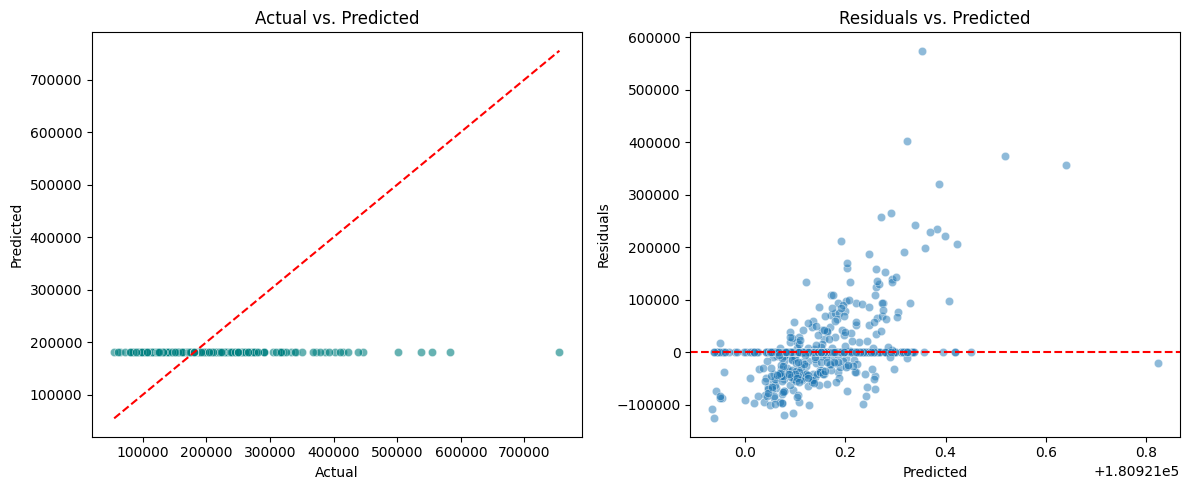

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted
sns.scatterplot(x=y_valid, y=Y_pred, ax=axes[0], color='teal', alpha=0.6)
axes[0].plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], color='red', linestyle='--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs. Predicted')

# Residuals
sns.scatterplot(x=Y_pred, y=residuals, ax=axes[1], alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs. Predicted')

plt.tight_layout()
plt.show()


In [38]:
from sklearn.ensemble import RandomForestRegressor

model_RFR = RandomForestRegressor(n_estimators=10)
model_RFR.fit(x_train, y_train)
Y_pred = model_RFR.predict(x_valid)

mean_absolute_percentage_error(y_valid, Y_pred)

0.18462594543863367

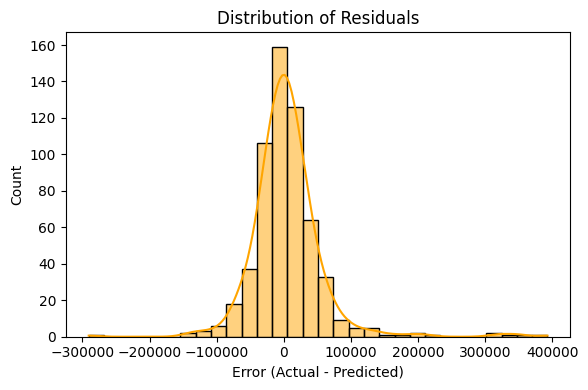

In [39]:
residuals = y_valid - Y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True, color='orange')
plt.title('Distribution of Residuals')
plt.xlabel('Error (Actual - Predicted)')
plt.tight_layout()
plt.show()


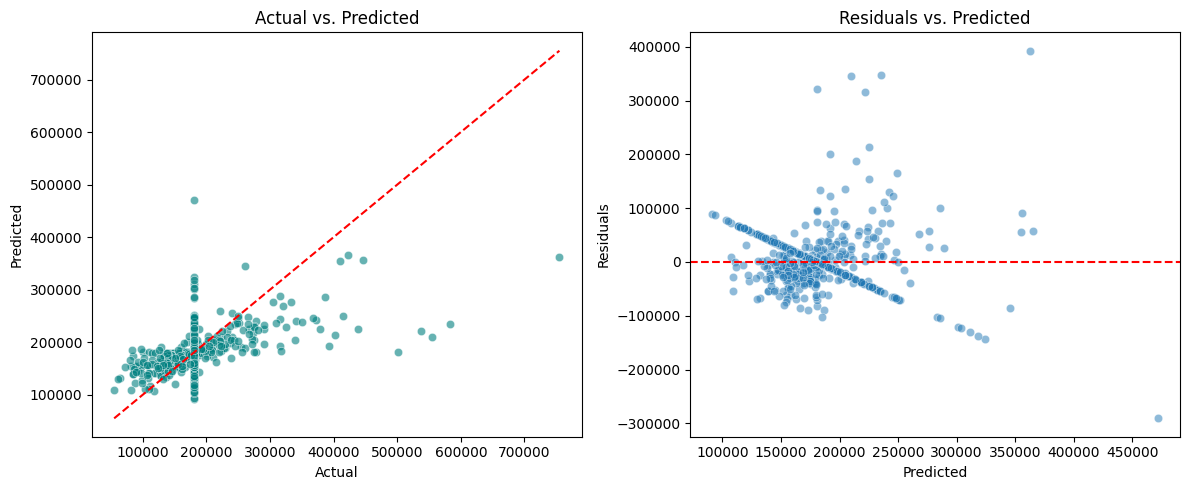

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted
sns.scatterplot(x=y_valid, y=Y_pred, ax=axes[0], color='teal', alpha=0.6)
axes[0].plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], color='red', linestyle='--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs. Predicted')

# Residuals
sns.scatterplot(x=Y_pred, y=residuals, ax=axes[1], alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs. Predicted')

plt.tight_layout()
plt.show()


In [41]:
from sklearn.ensemble import GradientBoostingRegressor

model_GBR = GradientBoostingRegressor()
model_GBR.fit(x_train, y_train)
Y_pred = model_GBR.predict(x_valid)

mean_absolute_percentage_error(y_valid, Y_pred)

0.18435674809376815

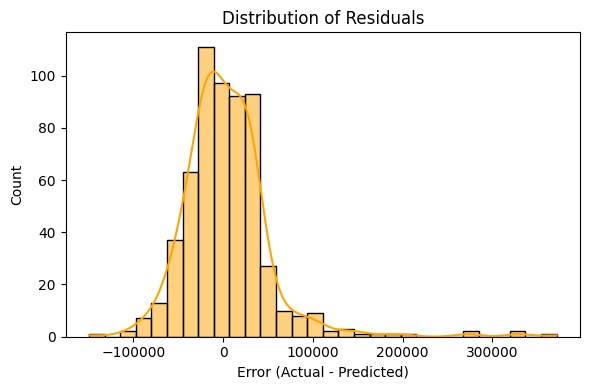

In [42]:
residuals = y_valid - Y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True, color='orange')
plt.title('Distribution of Residuals')
plt.xlabel('Error (Actual - Predicted)')
plt.tight_layout()
plt.show()


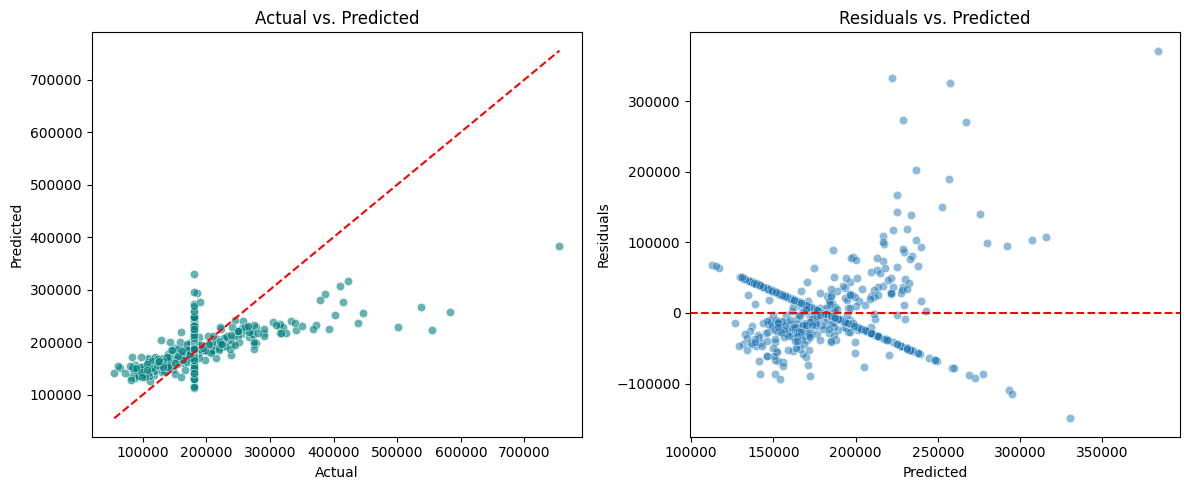

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted
sns.scatterplot(x=y_valid, y=Y_pred, ax=axes[0], color='teal', alpha=0.6)
axes[0].plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], color='red', linestyle='--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs. Predicted')

# Residuals
sns.scatterplot(x=Y_pred, y=residuals, ax=axes[1], alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs. Predicted')

plt.tight_layout()
plt.show()


In [44]:
#### Comparision

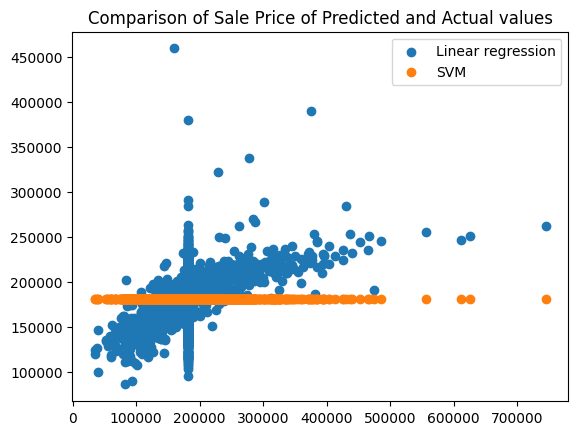

In [45]:
plt.figure()
plt.title('Comparison of Sale Price of Predicted and Actual values')
plt.scatter(y_train,model_LR.predict(x_train),label='Linear regression')
plt.scatter(y_train,model_SVR.predict(x_train),label='SVM')
plt.legend()

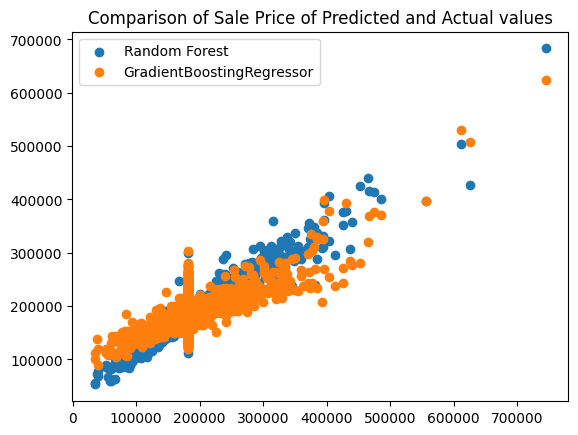

In [46]:
plt.figure()
plt.title('Comparison of Sale Price of Predicted and Actual values')
plt.scatter(y_train,model_RFR.predict(x_train),label='Random Forest')
plt.scatter(y_train,model_GBR.predict(x_train),label='GradientBoostingRegressor')
plt.legend()

#### Summary

In this project, I built a regression models to predict house sale prices using the HousePriceMerged dataset. The data included 13 features describing lot size, building type, zoning classification, condition ratings, and structural details of residential properties.

#### Key Steps:
- Data Cleaning: Inspected data types, handled categorical and numerical features, removed irrelevant columns, and encoded categorical variables using OneHotEncoding.

- EDA: Visualized distributions, relationships, and correlations using histograms, countplots, scatterplots, boxplots, heatmaps, pairplots, and residual plots to understand trends and feature importance.

- Feature Engineering: Created dummy variables for categorical columns, explored skewness in numerical features, and selected meaningful predictors for modeling.

- Modeling: Split the data into training and validation sets. Trained a Linear Regression model and evaluated it using Mean Absolute Percentage Error (MAPE).

- Visualization of Results: Plotted Actual vs. Predicted values, residual distributions, and residual vs. predicted scatterplots to assess model fit and error patterns.

#### Outcome:
Developed a regression model capable of estimating house sale prices with interpretable insights on key drivers of pricing. This predictive tool supports data-driven real-estate valuation and investment decisions.